<a href="https://colab.research.google.com/github/JCarnelosMV/Image_Analysis/blob/main/C%C3%B3pia_de_PorosidadeMEV_pacotes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!ls -lt

total 36
-rw-r--r-- 1 root root   44 Aug  6 16:22  requirements.txt
-rw-r--r-- 1 root root 3783 Aug  6 16:22  script_atualizado.py
-rw-r--r-- 1 root root 1969 Aug  6 16:22  script_mev.py
drwxr-xr-x 8 root root 4096 Aug  6 16:22  images
-rw-r--r-- 1 root root 1408 Aug  6 16:22 'Porosity analysis_0.ipynb'
-rw-r--r-- 1 root root 3947 Aug  6 16:22  Porosity_calculation_MEV
-rw-r--r-- 1 root root  318 Aug  6 16:22  README.md
-rw-r--r-- 1 root root 1396 Aug  6 16:22  Untitled0.ipynb
-rw-r--r-- 1 root root   38 Aug  6 16:22  Porosity


fatal: not a git repository (or any of the parent directories): .git
Total de imagens encontradas: 6

Processando: /content/Image_Analysis/images/GelMA_ctrl/5 (sem_barra).tif


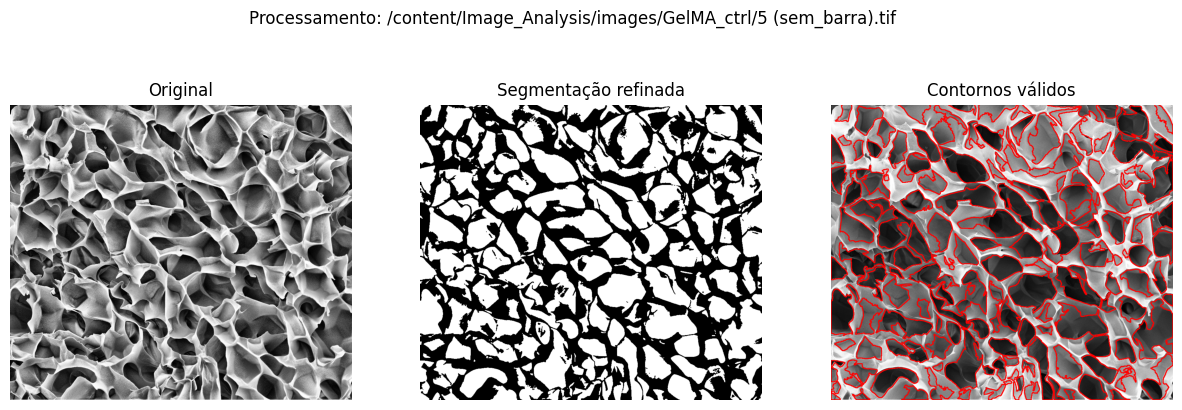


--- RESULTADOS ---
Poros detectados: 129
Diâmetro médio (µm): 6.089
Porosidade (%): 54.44
-----------------------------------------

Processando: /content/Image_Analysis/images/GelMA_ctrl/1 (sem_barra).tif


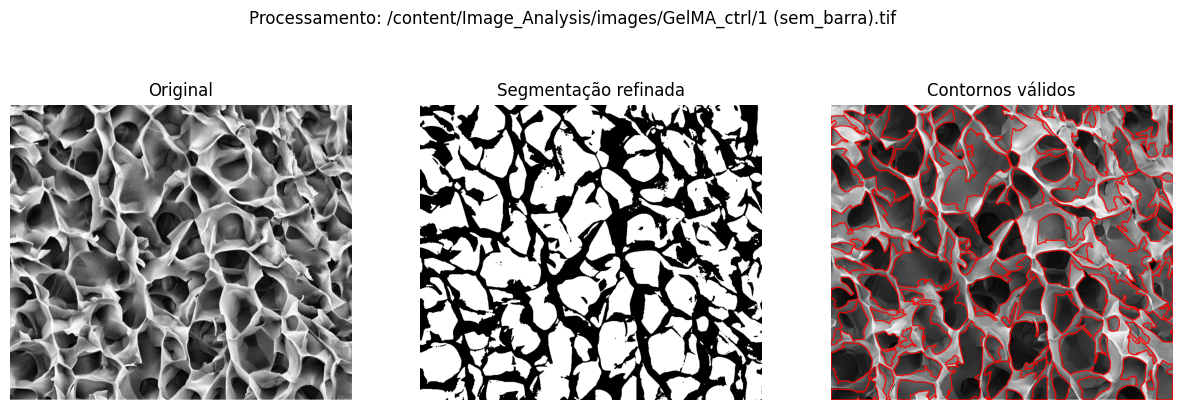


--- RESULTADOS ---
Poros detectados: 80
Diâmetro médio (µm): 7.908
Porosidade (%): 58.86
-----------------------------------------

Processando: /content/Image_Analysis/images/GelMA_ctrl/3 (sem_barra).tif


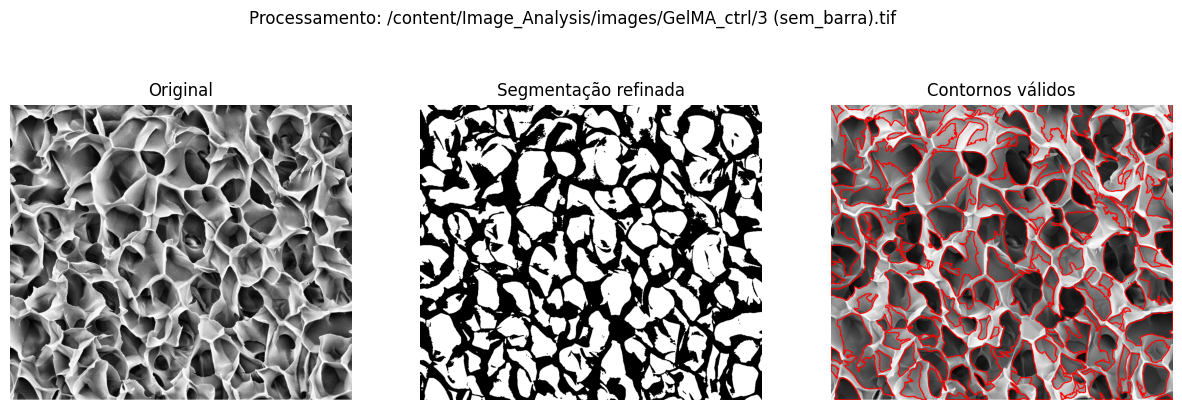


--- RESULTADOS ---
Poros detectados: 106
Diâmetro médio (µm): 6.667
Porosidade (%): 54.19
-----------------------------------------

Processando: /content/Image_Analysis/images/GelMA_ctrl/6 (sem_barra).tif


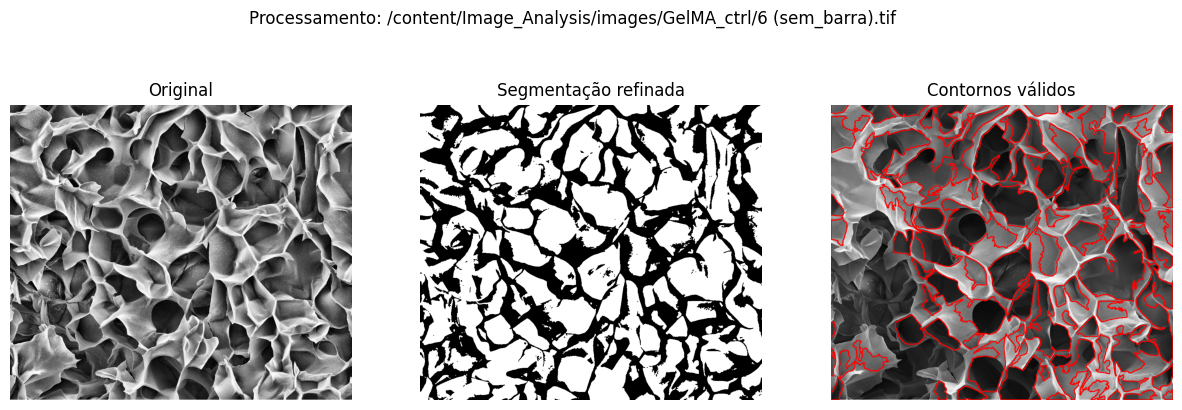


--- RESULTADOS ---
Poros detectados: 73
Diâmetro médio (µm): 7.525
Porosidade (%): 59.44
-----------------------------------------

Processando: /content/Image_Analysis/images/GelMA_ctrl/2 (sem_barra).tif


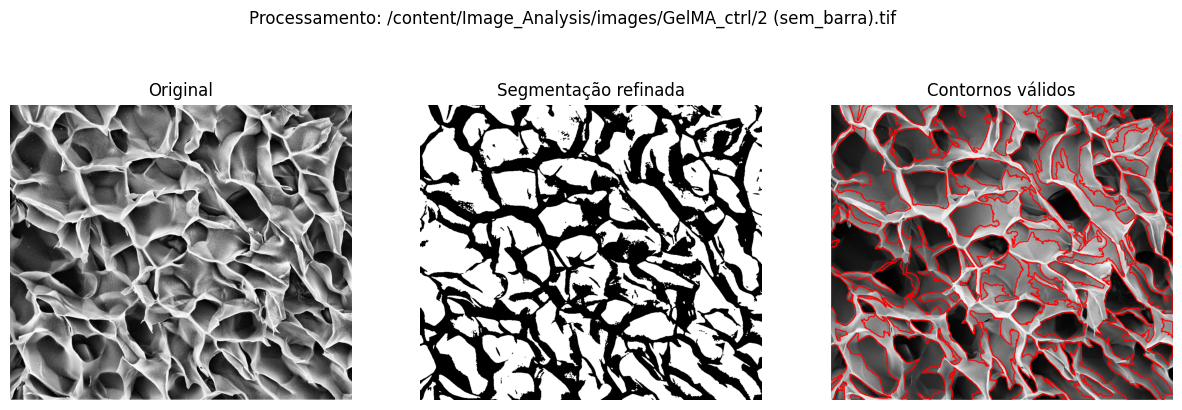


--- RESULTADOS ---
Poros detectados: 71
Diâmetro médio (µm): 8.113
Porosidade (%): 57.83
-----------------------------------------

Processando: /content/Image_Analysis/images/GelMA_ctrl/4 (sem_barra).tif


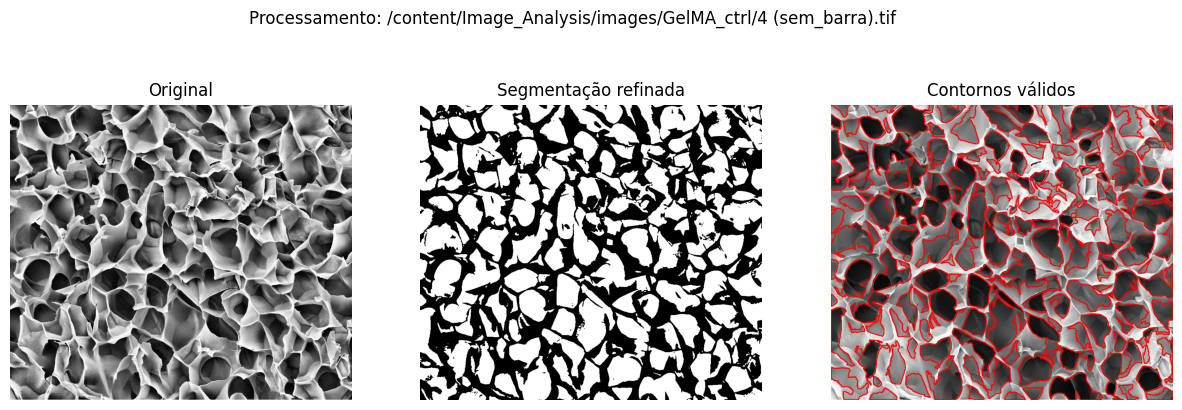


--- RESULTADOS ---
Poros detectados: 126
Diâmetro médio (µm): 6.123
Porosidade (%): 54.65
-----------------------------------------


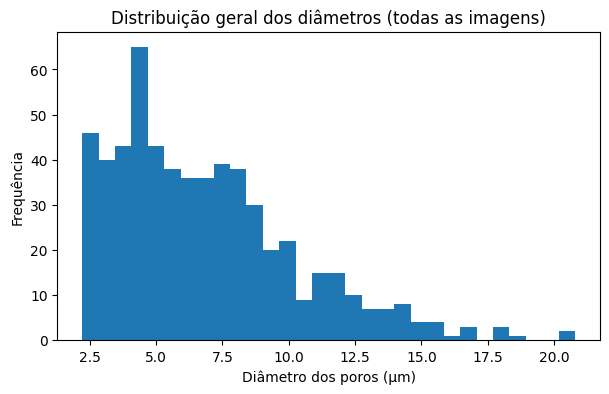


========== RESULTADOS GERAIS ==========
Total de imagens: 6
Total de poros detectados: 585
Diâmetro médio geral (µm): 6.875
Porosidade média (%): 56.57


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob
!git pull

# ======================================================
# 1) CONFIGURAÇÕES
# ======================================================

pixel_size = 100 / 1024   # µm por pixel (ajuste conforme sua imagem)
min_area_px = 400
min_circularity = 0.05

# pasta com as imagens
folder = "/content/Image_Analysis/images/GelMA_ctrl/*.tif"   # ajuste: png, tiff etc.

image_list = glob.glob(folder)
print(f"Total de imagens encontradas: {len(image_list)}")

# listas acumuladas
all_diameters = []
all_areas = []
porosities = []

# ======================================================
# LOOP EM TODAS AS IMAGENS
# ======================================================

for img_path in image_list:

    print(f"\nProcessando: {img_path}")

    # 2) CARREGAR IMAGEM
    image = cv2.imread(img_path)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    clahe = cv2.createCLAHE(
    clipLimit=4.0,
    tileGridSize=(16,16)
)

    gray = clahe.apply(gray)

    gray_blur = cv2.GaussianBlur(gray, (3,3), 0)

    # 3) SEGMENTAÇÃO OTSU
    _, thresh = cv2.threshold(
    gray_blur,
    130,
    255,
    cv2.THRESH_BINARY_INV
)


    # 4) MORFOLOGIA
    kernel = np.ones((2,2), np.uint8)
    clean = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=1)
    clean = cv2.morphologyEx(clean, cv2.MORPH_OPEN, kernel, iterations=1)

    # 5) CONTORNOS
    contours, _ = cv2.findContours(clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    valid_contours = []
    diameters_um = []
    areas_um2 = []

    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < min_area_px:
            continue

        per = cv2.arcLength(cnt, True)
        circularity = 4 * np.pi * (area / (per*per + 1e-6))

        if circularity < min_circularity:
            continue

        area_um2 = area * (pixel_size ** 2)
        areas_um2.append(area_um2)

        diam = 2 * np.sqrt(area_um2 / np.pi)
        diameters_um.append(diam)

        valid_contours.append(cnt)

    # acumula nos dados gerais
    all_diameters.extend(diameters_um)
    all_areas.extend(areas_um2)

    # porosidade de cada imagem
    total_pixels = clean.size
    poro_pixels = clean.sum() / 255
    porosity_percent = (poro_pixels / total_pixels) * 100
    porosities.append(porosity_percent)

    # ======================================================
    # PLOT DA SEGMENTAÇÃO DE CADA IMAGEM
    # ======================================================

    plt.figure(figsize=(15,5))
    plt.suptitle(f"Processamento: {img_path}")

    plt.subplot(1,3,1)
    plt.title("Original")
    plt.imshow(gray, cmap='gray')
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.title("Segmentação refinada")
    plt.imshow(clean, cmap='gray')
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.title("Contornos válidos")
    img_c = image.copy()
    cv2.drawContours(img_c, valid_contours, -1, (0,0,255), 2)
    plt.imshow(cv2.cvtColor(img_c, cv2.COLOR_BGR2RGB))
    plt.axis("off")

    plt.show()

    print("\n--- RESULTADOS ---")
    print(f"Poros detectados: {len(valid_contours)}")
    print(f"Diâmetro médio (µm): {np.mean(diameters_um):.3f}")
    print(f"Porosidade (%): {porosity_percent:.2f}")
    print("-----------------------------------------")

# ======================================================
# HISTOGRAMA FINAL — MÉDIA DO PACOTE
# ======================================================

plt.figure(figsize=(7,4))
plt.hist(all_diameters, bins=30)
plt.xlabel("Diâmetro dos poros (µm)")
plt.ylabel("Frequência")
plt.title("Distribuição geral dos diâmetros (todas as imagens)")
plt.show()

print("\n========== RESULTADOS GERAIS ==========")
print(f"Total de imagens: {len(image_list)}")
print(f"Total de poros detectados: {len(all_diameters)}")
print(f"Diâmetro médio geral (µm): {np.mean(all_diameters):.3f}")
print(f"Porosidade média (%): {np.mean(porosities):.2f}")
print("========================================")

